In [1]:
import sys
print(sys.path)

sys.path.insert(1, '/home/andreas/prj_AH/analysis_buckle/') ## this is the path to the pybuckle package.
                                                            ## only necessary if the location is not in your
                                                            ## python path
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import MDAnalysis as mda
from MDAnalysis import transformations
import nglview as nv

# from scipy.interpolate import UnivariateSpline
# from scipy.interpolate import interp1d
# from scipy.interpolate import CubicSpline, PchipInterpolator
# from scipy.optimize import curve_fit, least_squares, leastsq, minimize, fsolve
# from scipy.integrate import quad, cumtrapz, solve_bvp

from pybuckle.fourier import *
from pybuckle.solveBVP import BuckleBVPSolver, makeTables
from pybuckle.getshapecoeff import BucklesShapeFCoeff
from pybuckle.fitshape import FitShape, prefit_fun
from pybuckle.misc import min_image_dist, rotateVec

SMALL_SIZE = 16
MEDIUM_SIZE = 20 
BIGGER_SIZE = 24

plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)

['/home/andreas/prj_AH/buckle_hecate_x', '/usr/lib/python38.zip', '/usr/lib/python3.8', '/usr/lib/python3.8/lib-dynload', '', '/home/andreas/.local/lib/python3.8/site-packages', '/usr/local/lib/python3.8/dist-packages', '/usr/local/lib/python3.8/dist-packages/memsurfer-1.1.0-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/vtk-9.2.0rc2-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/numpy-1.23.2-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/wslink-1.7.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/matplotlib-3.5.3-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/aiohttp-3.8.1-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/kiwisolver-1.4.4-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/fonttools-4.35.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/cycler-0.11.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/yarl-1.8.1-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.

In [2]:
%load_ext autoreload
#%load_ext line_profiler

%autoreload 2

In [3]:
#basedir = '/home/andreas/prj_AH/analysis_buckle/'
basedir = '/home/andreas/prj_AH/buckle_hecate_x/'
#workdir = basedir + 'sampling/pull/'
workdir = basedir
umbdir = workdir + 'UMBRELLA/'

# this gives L0, i.e., the membrane length. As a large membrane will have undulations, it can be useful to
# suppress undulations with position restraints in z-direction
#membraneOnly_box_x = np.loadtxt(basedir + 'membraneOnly/NPT/box-x.xvg', skiprows=24)

#u = mda.Universe(workdir + 'pull.tpr', workdir + 'pull_stride100.xtc')
u = mda.Universe(workdir + 'pull.tpr', workdir + 'pull_reduced.xtc' )

lx = u.dimensions[0] / 10
ly = u.dimensions[1] / 10
lz = u.dimensions[2] / 10
print(lx, ly, lz)

#L0 = np.mean(membraneOnly_box_x[:,1])
L0 = 30
print('L0 = %f' %L0)
Lx = lx
g = Lx / L0
print(g)

21.0 10.0 22.20881042480469
L0 = 30.000000
0.7


In [4]:
plt.rcParams['figure.figsize'] = 14, 14 #/ aspect_ratio
plt.rcParams['legend.fontsize'] = SMALL_SIZE

In [5]:
#protein = u.select_atoms('moltype Protein')
protein = u.select_atoms('moltype Protein_A')
protein

<AtomGroup with 36 atoms>

In [6]:
po4 = u.select_atoms('name PO4')

Look at pull trajectory with nglview. This is just an easy way to make sure that the whole range you want to sample is covered and that the molecule, that is pulled, is attached to the membrane everywhere in this range.  Obviously this part can be done outside the notebook, with any visualization software you like. In this case we were only interested in the positively curved region. Before the pulling simulation, I arange the membrane inside the simulation box such that s = -0.25 is at x = 0 and s = 0.75 is at x = x_max. (Like in Figure 3 in the paper.) Everything is tested only in this configuration.

In [7]:
view = nv.show_mdanalysis(protein)
#view.clear()

view.add_trajectory(po4)
view.add_unitcell()
view.control.rotate(
   mda.lib.transformations.quaternion_from_euler(
       -np.pi/2, np.pi, 0, 'rzyz').tolist())
view.control.zoom(.6)
view.camera = 'orthographic'
view._remote_call("setSize", target="Widget", args=["1000px", "1000px"])

view.add_ball_and_stick('protein' )


In [8]:
view

NGLWidget(max_frame=399)

In [9]:
fitter = FitShape(Lx, g) # This instance of the FitShape class takes care of the fitting.
outsideshaper = BucklesShapeFCoeff()

In [10]:
curve_atoms = u.select_atoms('name C4A C4B')
len(curve_atoms)

1610

In [11]:
len(u.trajectory)

400

In [12]:
frame_stride = 1 # the example trajectory has a large stride already, for reduction of size 
start_frame = 0 # len(gro.trajectory) * 1 // 4
print(start_frame)

nFrames = (len(u.trajectory) - start_frame) // frame_stride #+ 1
print(nFrames)

0
400


In [13]:
## estimated time, with roughly 3 s per frame
t_est = 3 * nFrames / 3600
print('estimated time = %f h, or %f min' %(t_est, t_est*60))

estimated time = 0.333333 h, or 20.000000 min


Actual fitting of the membrane shape and projection onto s of the probe molecules is done in the next step.

In [14]:
fit_scores = np.zeros(nFrames)
minim_g_out_all = np.zeros((nFrames, 3 + len(curve_atoms)))
axAllFrames = np.zeros((nFrames, 7))
azAllFrames = np.zeros((nFrames, 8))
u.trajectory[start_frame]

s_protein = np.zeros(nFrames)
protein_coords = np.zeros((nFrames, 3))

for i, frame in enumerate(u.trajectory[start_frame::frame_stride]):
    print(frame.time)
    curve_atoms = u.select_atoms('name C4A C4B')
    po4_atoms = u.select_atoms('name PO4')
    po4_coords = po4_atoms.positions / 10
    #protein = u.select_atoms('moltype Protein')
    protein = u.select_atoms('moltype Protein_A')

    x = curve_atoms.positions[:,0] / 10
    z = curve_atoms.positions[:,2] / 10
    xz_combined = np.column_stack([x, z])
    
    fitter.do_prefit(xz_combined)
    minim_g_out, ax_at_fitted_g, az_at_fitted_g = fitter.fit(xz_combined)
    minim_g_out_all[i,:] = minim_g_out.x
    axAllFrames[i,:] = ax_at_fitted_g
    azAllFrames[i,:] = az_at_fitted_g
    fit_scores[i] = minim_g_out.fun
    
    x0 = minim_g_out.x[0]
    z0 = minim_g_out.x[1]
    
    s_plot = np.linspace(fitter.s_min, fitter.s_max, int(1e4)+1)
    X_plot = fs_x(s_plot, *ax_at_fitted_g) * lx
    Z_plot = fs_z(s_plot, *az_at_fitted_g) * lx  
    
    protein_com = protein.center_of_mass() / 10
    protein_coords[i,:] = protein_com
    
    #dx_loop = calcDist_min_image(x0 + X_plot, loop_com[0], lx)
    dx_protein = min_image_dist(x0 + X_plot, protein_com[0], lx)
    projected_s_indices_protein = np.argmin((dx_protein)**2 +
                                       (z0 + Z_plot - protein_com[2])**2, axis=0 )
    s_protein[i] = s_plot[projected_s_indices_protein].reshape(-1)

120987.8984375
121987.796875
122987.703125
123987.6015625
124987.5
125987.3984375
126987.296875
127987.203125
128987.1015625
129987.0
130986.8984375
131986.796875
132986.703125
133986.59375
134986.5
135986.40625
136986.296875
137986.203125
138986.09375
139986.0
140985.90625
141985.796875
142985.703125
143985.59375
144985.5
145985.40625
146985.296875
147985.203125
148985.09375
149985.0
150984.90625
151984.796875
152984.703125
153984.59375
154984.5
155984.40625
156984.296875
157984.203125
158984.09375
159984.0
160983.90625
161983.796875
162983.703125
163983.59375
164983.5
165983.40625
166983.296875
167983.203125
168983.09375
169983.0
170982.90625
171982.796875
172982.703125
173982.59375
174982.5
175982.40625
176982.296875
177982.203125
178982.09375
179982.0
180981.90625
181981.796875
182981.703125
183981.59375
184981.5
185981.40625
186981.296875
187981.203125
188981.09375
189981.0
190980.90625
191980.796875
192980.703125
193980.59375
194980.5
195980.40625
196980.296875
197980.203125
1989

In [15]:
x0_mean = np.mean(minim_g_out_all[:,0])
x0_std  = np.std(minim_g_out_all[:,0])

z0_mean = np.mean(minim_g_out_all[:,1])
z0_std  = np.std(minim_g_out_all[:,1])

g_mean = np.mean(minim_g_out_all[:,2])
g_std  = np.std(minim_g_out_all[:,2])

print(x0_mean, x0_std, x0_std / x0_mean)
print(z0_mean, z0_std, z0_std / z0_mean)
print(g_mean,  g_std,  g_std  / g_mean)

6.324593441832892 0.03584137143971802 0.005666984252719184
6.06268273841992 0.033676529948788045 0.005554724105118678
0.7293539059803824 0.0024897769079824713 0.003413674606480327


In [16]:
#s_plot = np.linspace(fitter.s_min, fitter.s_max, 201)
fitted_shape_coeff = outsideshaper.get_FCoeff(g_mean, Lx,
                                     s=(s_plot))

ax_at_fitted_g = fitted_shape_coeff[12]
az_at_fitted_g = fitted_shape_coeff[13]
X = fitted_shape_coeff[0]
Z = fitted_shape_coeff[1]
# dXdg = fitted_shape_coeff[2]
# dZdg = fitted_shape_coeff[3]
# dXds = fitted_shape_coeff[4]
# dZds = fitted_shape_coeff[5]
# d2Xdg2 = fitted_shape_coeff[6]
# d2Zdg2 = fitted_shape_coeff[7]
# d2Xds2 = fitted_shape_coeff[8]
# d2Zds2 = fitted_shape_coeff[9]
# d2Xdsdg = fitted_shape_coeff[10]
# d2Zdsdg = fitted_shape_coeff[11]

# d3Xds3 = fitted_shape_coeff[14]
# d3Zds3 = fitted_shape_coeff[15]

Save fit results to a hdf5 file. This will be used in the analysis.

In [17]:
# make directory: UMBRELLA if it does not exist already
# remove file shape_data.h5 if it already exists
hf = h5py.File(umbdir + 'shape_data.h5', 'w')

hf.create_dataset('minim_g_out_all', data=minim_g_out_all)
shape_grp = hf.create_group('shape_coeff')
shape_grp.create_dataset('g_mean', data=g_mean)
shape_grp.create_dataset('Lx', data=Lx)
shape_grp.create_dataset('s_plot', data=s_plot)

hf.close()

In [18]:
solver = BuckleBVPSolver(g_mean, 10001)
s01 = np.linspace(0, 1, 10001)

Select the range of s values, i.e., the reaction coordinate and number of umbrella windows

In [19]:
#s_window = np.linspace(0.25, 0.5, 32) # In this case, we were only interested in the positively curved region  
s_window = np.linspace(0.0, 0.5, 64) # In this case, we were only interested in the positively curved region 
s_window

array([0.        , 0.00793651, 0.01587302, 0.02380952, 0.03174603,
       0.03968254, 0.04761905, 0.05555556, 0.06349206, 0.07142857,
       0.07936508, 0.08730159, 0.0952381 , 0.1031746 , 0.11111111,
       0.11904762, 0.12698413, 0.13492063, 0.14285714, 0.15079365,
       0.15873016, 0.16666667, 0.17460317, 0.18253968, 0.19047619,
       0.1984127 , 0.20634921, 0.21428571, 0.22222222, 0.23015873,
       0.23809524, 0.24603175, 0.25396825, 0.26190476, 0.26984127,
       0.27777778, 0.28571429, 0.29365079, 0.3015873 , 0.30952381,
       0.31746032, 0.32539683, 0.33333333, 0.34126984, 0.34920635,
       0.35714286, 0.36507937, 0.37301587, 0.38095238, 0.38888889,
       0.3968254 , 0.4047619 , 0.41269841, 0.42063492, 0.42857143,
       0.43650794, 0.44444444, 0.45238095, 0.46031746, 0.46825397,
       0.47619048, 0.48412698, 0.49206349, 0.5       ])

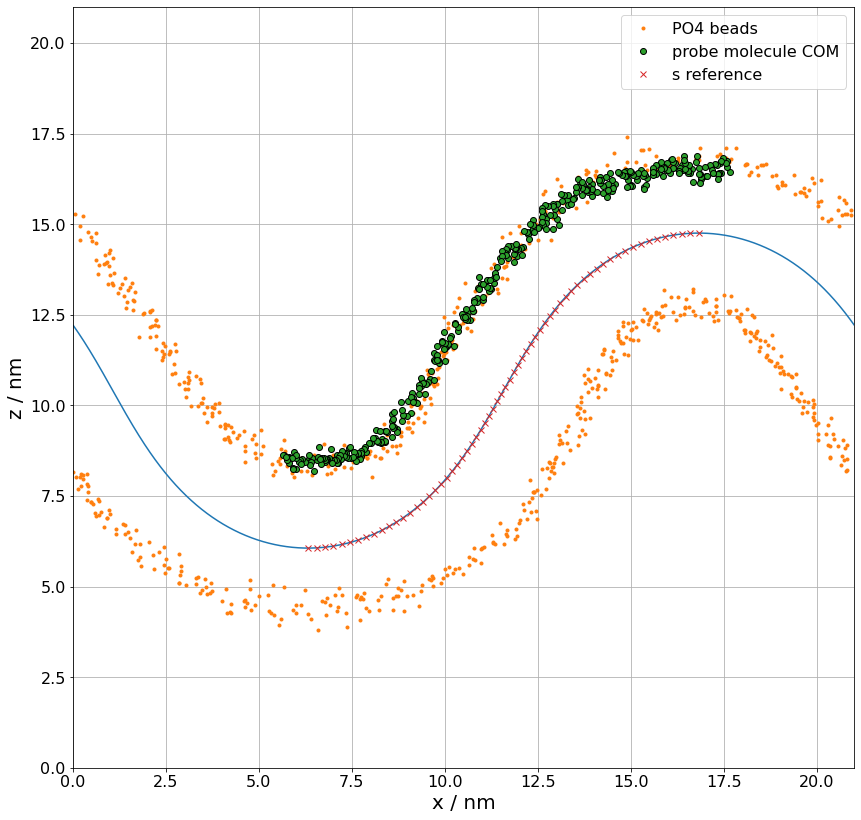

In [20]:
colors = ["C0", "C1", 'C2', 'C3', "C4", 'C5', 'C6', 'C7', 'C8', 'C9', 'C10']
fig, ax = plt.subplots(figsize=(14, 14))


plt.plot(x0_mean + X, z0_mean + Z)
plt.plot(po4_coords[:,0], po4_coords[:,2], '.', label='PO4 beads')


plt.plot(protein_coords[:,0], protein_coords[:,2], 'o', markeredgecolor=(0, 0, 0, 1),
        label='probe molecule COM')


plt.plot(x0_mean + fs_x(s_window, *ax_at_fitted_g) * lx,
         z0_mean + fs_z(s_window, *az_at_fitted_g) * lx, 'x',
        label='s reference')
 



plt.xlabel('x / nm')
plt.ylabel('z / nm')
plt.xlim(0, lx)
plt.ylim(0, lx)

plt.legend()

plt.grid()
plt.show()

In [21]:
ds = np.abs(s_protein.reshape(-1,1) - s_window.reshape(1,-1))

In [22]:
# this selects the 
s_protein_indices_min = np.argmin(ds, axis=0)
s_protein_indices_min

array([374, 377, 370, 371, 366, 357, 354, 356, 349, 340, 339, 326, 327,
       322, 323, 321, 320, 308, 317, 312, 301, 303, 302, 294, 291, 289,
       288, 276, 272, 271, 269, 261, 266, 248, 251, 243, 246, 240, 229,
       226, 221, 224, 212, 206, 204, 186, 197, 181, 178, 162, 154, 148,
       145, 138, 121, 117, 100,  94,  80,  69,  63,  42,  40,  27])

In [23]:
# translate indices to frame indices of the trajectory (if stride > 1 and start frame > 0)
np.sort(s_protein_indices_min * frame_stride + start_frame)

array([ 27,  40,  42,  63,  69,  80,  94, 100, 117, 121, 138, 145, 148,
       154, 162, 178, 181, 186, 197, 204, 206, 212, 221, 224, 226, 229,
       240, 243, 246, 248, 251, 261, 266, 269, 271, 272, 276, 288, 289,
       291, 294, 301, 302, 303, 308, 312, 317, 320, 321, 322, 323, 326,
       327, 339, 340, 349, 354, 356, 357, 366, 370, 371, 374, 377])

In [24]:
for frame in u.trajectory[s_protein_indices_min * frame_stride + start_frame]:
    print(frame.time)

494950.5
497950.1875
490950.90625
491950.8125
486951.3125
477952.1875
474952.5
476952.3125
469953.0
460953.90625
459954.0
446955.3125
447955.1875
442955.6875
443955.59375
441955.8125
440955.90625
428957.09375
437956.1875
432956.6875
421957.8125
423957.59375
422957.6875
414958.5
411958.8125
409959.0
408959.09375
396960.3125
392960.6875
391960.8125
389961.0
381961.8125
386961.3125
368963.09375
371962.8125
363963.59375
366963.3125
360963.90625
349965.0
346965.3125
341965.8125
344965.5
332966.6875
326967.3125
324967.5
306969.3125
317968.1875
301969.8125
298970.09375
282971.6875
274972.5
268973.09375
265973.40625
258974.09375
241975.796875
237976.203125
220977.90625
214978.5
200979.90625
189981.0
183981.59375
162983.703125
160983.90625
147985.203125


Calculate tangents and normal vectors

In [25]:
tangents = np.zeros((s_window.shape[0], 3)) 
for i in range(s_window.shape[0]):
    idx = np.argmin(np.abs(s01 - s_window[i]))
    s_tang = s01[idx]
    theta_i = solver.thetaSol_shifted[idx]
    tangents[i,:] = rotateVec(np.array([1, 0, 0]), theta_i)
    


In [26]:
normals = np.zeros((s_window.shape[0], 3)) 
for i in range(s_window.shape[0]):
    idx = np.argmin(np.abs(s01 - s_window[i]))
    s_tang = s01[idx]
    theta_i = solver.thetaSol_shifted[idx] + np.pi / 2
    normals[i,:] = rotateVec(np.array([1, 0, 0]), theta_i)

Plot tangents and probe molecule COM at selected frames

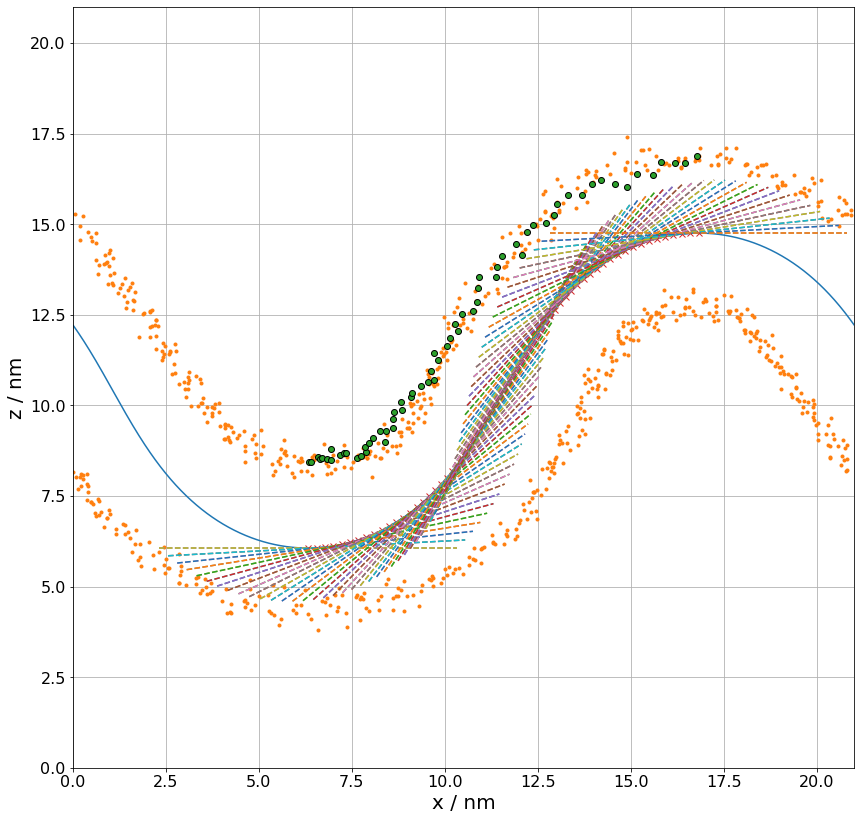

In [27]:
colors = ["C0", "C1", 'C2', 'C3', "C4", 'C5', 'C6', 'C7', 'C8', 'C9', 'C10']
fig, ax = plt.subplots(figsize=(14, 14))


plt.plot(x0_mean + X, z0_mean + Z)
plt.plot(po4_coords[:,0], po4_coords[:,2], '.')


plt.plot(protein_coords[s_protein_indices_min,0], 
         protein_coords[s_protein_indices_min,2], 
         'o', 
         markeredgecolor=(0, 0, 0, 1))


plt.plot(x0_mean + fs_x(s_window, *ax_at_fitted_g) * lx,
         z0_mean + fs_z(s_window, *az_at_fitted_g) * lx, 'x')


# plt.plot(x0_mean + fs_x(s_window, *ax_at_fitted_g) * lx,
#          z0_mean + fs_z(s_window, *az_at_fitted_g) * lx + 2.2, 'x')


for i in range(0, s_window.shape[0], 1):
    x_win = fs_x(s_window, *ax_at_fitted_g) * lx
    z_win = fs_z(s_window, *az_at_fitted_g) * lx
    plt.plot([x0_mean + x_win[i] - 4 * tangents[i,0], 
              x0_mean + x_win[i] + 4 * tangents[i,0]],
             [z0_mean + z_win[i] - 4 * tangents[i,2],
              z0_mean + z_win[i] + 4 * tangents[i,2]], '--')
    
for i in range(0, s_window.shape[0], 1):
    x_win = fs_x(s_window, *ax_at_fitted_g) * lx
    z_win = fs_z(s_window, *az_at_fitted_g) * lx
    plt.plot([x0_mean + x_win[i] - 4 * tangents[i,0], 
              x0_mean + x_win[i] + 4 * tangents[i,0]],
             [z0_mean + z_win[i] - 4 * tangents[i,2],
              z0_mean + z_win[i] + 4 * tangents[i,2]], '--')
  
    



plt.xlabel('x / nm')
plt.ylabel('z / nm')
plt.xlim(0, lx)
plt.ylim(0, lx)


plt.grid()
plt.show()

In [28]:
delta_s_frames = np.zeros_like(s_protein[s_protein_indices_min])
delta_s_frames[1:] = np.flip(s_protein[s_protein_indices_min])[1:] - np.flip(s_protein[s_protein_indices_min])[:-1]
delta_s_frames

array([ 0.        , -0.00883424, -0.00723157, -0.00795898, -0.00642586,
       -0.00936295, -0.00796823, -0.00897322, -0.00668848, -0.00805075,
       -0.00801386, -0.00866491, -0.00756841, -0.00744192, -0.00853079,
       -0.00814184, -0.00706482, -0.0091684 , -0.00679981, -0.00825826,
       -0.00745583, -0.00804947, -0.00668416, -0.00849715, -0.00930434,
       -0.007807  , -0.00774325, -0.0104978 , -0.0048769 , -0.0075564 ,
       -0.00860423, -0.01067688, -0.00572266, -0.01157706, -0.00611516,
       -0.00514886, -0.00728754, -0.01019363, -0.00698879, -0.00891605,
       -0.00719871, -0.00676258, -0.00850759, -0.00936316, -0.00876817,
       -0.00526127, -0.00849709, -0.00911769, -0.00789149, -0.00995592,
       -0.00436805, -0.00980752, -0.00636266, -0.00706626, -0.00765802,
       -0.00968283, -0.00750896, -0.00768365, -0.00751859, -0.00950661,
       -0.00606588, -0.00826237, -0.00827673, -0.00927132])

In [29]:
frames = np.sort(s_protein_indices_min * frame_stride + start_frame)
frames

array([ 27,  40,  42,  63,  69,  80,  94, 100, 117, 121, 138, 145, 148,
       154, 162, 178, 181, 186, 197, 204, 206, 212, 221, 224, 226, 229,
       240, 243, 246, 248, 251, 261, 266, 269, 271, 272, 276, 288, 289,
       291, 294, 301, 302, 303, 308, 312, 317, 320, 321, 322, 323, 326,
       327, 339, 340, 349, 354, 356, 357, 366, 370, 371, 374, 377])

In [30]:
frame_data = np.column_stack((np.array(frames, dtype="int"), np.flip(s_protein[s_protein_indices_min]), delta_s_frames))
frame_info = pd.DataFrame(frame_data, columns=['frame', 's', 'ds'])
frame_info["frame"] = np.array(frames, dtype="int")
frame_info

,frame,s,ds
0,27,0.500231,0.000000
1,40,0.491397,-0.008834
2,42,0.484166,-0.007232
3,63,0.476207,-0.007959
4,69,0.469781,-0.006426
...,...,...,...
59,366,0.030894,-0.009507
60,370,0.024828,-0.006066
61,371,0.016566,-0.008262
62,374,0.008289,-0.008277


In [31]:
frame_info.to_csv(umbdir + 'caught-output.dat', sep='\t', index=False, header=True)

In [32]:
def writeGRO(filename, u, frame_idx):
    file = open(filename, 'w')
    file.write('conf for umbrella sampling\n')
    file.write("%d\n" %u.trajectory.n_atoms)
    ts = u.trajectory[frame_idx]
    print(ts.time)
    for atom in u.atoms:
        file.write("%5d%-5s%5s%5d%8.3f%8.3f%8.3f\n" %(atom.resid,
             atom.resname, atom.name, atom.id, atom.position[0] / 10,
             atom.position[1] / 10, atom.position[2] / 10))

    file.write("%10.5f%10.5f%10.5f\n" %(ts.dimensions[0] / 10,
                                            ts.dimensions[1] / 10, 
                                            ts.dimensions[2] / 10,))
    file.close()

The dummy positions are the reference positions, that go into the mdp files.

In [33]:

dummy_positions = np.zeros((s_window.shape[0], 3))    

dummy_positions[:,0] = x0_mean + fs_x(s_window, *ax_at_fitted_g) * lx
dummy_positions[:,1] = ly / 2
dummy_positions[:,2] = z0_mean + fs_z(s_window, *az_at_fitted_g) * lx

In [34]:
dummy_positions = np.flip(dummy_positions, axis=0)

Write starting configurations.

In [35]:
frames = np.sort(s_protein_indices_min * frame_stride + start_frame)
for i, frame in enumerate(frames):
    print(i, frame)
    writeGRO(umbdir + 'conf%d.gro' %frame, u, frame,)

0 27
147985.203125
1 40
160983.90625
2 42
162983.703125
3 63
183981.59375
4 69
189981.0
5 80
200979.90625
6 94
214978.5
7 100
220977.90625
8 117
237976.203125
9 121
241975.796875
10 138
258974.09375
11 145
265973.40625
12 148
268973.09375
13 154
274972.5
14 162
282971.6875
15 178
298970.09375
16 181
301969.8125
17 186
306969.3125
18 197
317968.1875
19 204
324967.5
20 206
326967.3125
21 212
332966.6875
22 221
341965.8125
23 224
344965.5
24 226
346965.3125
25 229
349965.0
26 240
360963.90625
27 243
363963.59375
28 246
366963.3125
29 248
368963.09375
30 251
371962.8125
31 261
381961.8125
32 266
386961.3125
33 269
389961.0
34 271
391960.8125
35 272
392960.6875
36 276
396960.3125
37 288
408959.09375
38 289
409959.0
39 291
411958.8125
40 294
414958.5
41 301
421957.8125
42 302
422957.6875
43 303
423957.59375
44 308
428957.09375
45 312
432956.6875
46 317
437956.1875
47 320
440955.90625
48 321
441955.8125
49 322
442955.6875
50 323
443955.59375
51 326
446955.3125
52 327
447955.1875
53 339
459954

Read in base mdp file. Subsequently one mdp file for each umbrella window is generated with the corresponding pull directions and reference positions.

In [36]:
mdpFile = open(umbdir + 'umbrella_new-rf_base.mdp', 'r' ) 
mdpLines = mdpFile.readlines()  

In [37]:
def writeMDP(mdpLines, filename, pull_coord1_vec, dummy_pos):
    file = open(filename, 'w')
    for line in mdpLines:
        if 'pull_coord1_vec' in line:
            print(line)
            newline = 'pull_coord1_vec         = %.5f 0.00000 %.5f\n' %(pull_coord1_vec[0], pull_coord1_vec[2])
            print(newline)
            file.write(newline)
        elif 'pull_coord1_origin' in line:
            print(line)
            newline = 'pull_coord1_origin      = %.3f %.3f %.3f\n' %(dummy_pos[0],
                                                                     dummy_pos[1],
                                                                     dummy_pos[2])
            print(newline)
            file.write(newline)
        else:
            file.write(line)
    
    

In [38]:
flipped_tangents = np.flip(tangents, axis=0) 
for i, frame in enumerate(frames):
    print(i, frame)
    writeMDP(mdpLines, umbdir + 'umbrella%d.mdp' %frame, flipped_tangents[i,:], dummy_positions[i,:])
#    writeMDP(mdpLines, umbdir + 'umbrella%d.mdp' %frame, tangents[i,:], dummy_positions[i,:])

0 27
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 1.00000 0.00000 0.00000

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 16.825 5.000 14.755

1 40
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.99851 0.00000 0.05455

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 16.596 5.000 14.749

2 42
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.99399 0.00000 0.10946

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 16.368 5.000 14.730

3 63
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.98662 0.00000 0.16305

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 16.142 5.000 14.699

4 69
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.97646 0.00000 0.21571

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 15.918 5.000 14.655

5 80
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.96348 0.00000 0.26779

pull_coord1_origin	= 0.0 

The umbrella simulation setups are done. Below are examples for generating scripts for GROMPPing and submission to the server. I usually package several windows into one SLURM job. Obviously, this depends on the server hardware and the simulation system size.

In [39]:
def makeGromppScript(frames, top_name):
    nFrames = int(frame_info['frame'].shape[0])

    frame_numbers= str(frame_info['frame'][0])
    for i in range(1, nFrames):
        frame_numbers += ' ' + str(frame_info['frame'][i]) 
             
    script_lines = []
    script_lines.append('#!/bin/bash\n\n') 
    
    script_lines.append('for i in %s\n' %frame_numbers)
    script_lines.append('\t do \n')
    grompp = '\t\tgmx grompp -f umbrella${i}.mdp -c conf${i}.gro -r conf${i}.gro '
    grompp += '-p %s -n index.ndx -o umbrella${i}.tpr \n\n' %top_name

    script_lines.append(grompp)
    
    script_lines.append('\ndone')
    
    return script_lines

In [40]:
grompp_lines = makeGromppScript(frame_info, 'pc100.top')
grompp_lines

['#!/bin/bash\n\n',
 'for i in 27 40 42 63 69 80 94 100 117 121 138 145 148 154 162 178 181 186 197 204 206 212 221 224 226 229 240 243 246 248 251 261 266 269 271 272 276 288 289 291 294 301 302 303 308 312 317 320 321 322 323 326 327 339 340 349 354 356 357 366 370 371 374 377\n',
 '\t do \n',
 '\t\tgmx grompp -f umbrella${i}.mdp -c conf${i}.gro -r conf${i}.gro -p pc100.top -n index.ndx -o umbrella${i}.tpr \n\n',
 '\ndone']

In [41]:
f1 = open(umbdir + 'do_grompp.sh', 'w')
for line in grompp_lines:
    f1.write(line)
    print(line)
f1.close()

#!/bin/bash


for i in 27 40 42 63 69 80 94 100 117 121 138 145 148 154 162 178 181 186 197 204 206 212 221 224 226 229 240 243 246 248 251 261 266 269 271 272 276 288 289 291 294 301 302 303 308 312 317 320 321 322 323 326 327 339 340 349 354 356 357 366 370 371 374 377

	 do 

		gmx grompp -f umbrella${i}.mdp -c conf${i}.gro -r conf${i}.gro -p pc100.top -n index.ndx -o umbrella${i}.tpr 



done


In [42]:
def makeSubmitScript(frames):
    frames = np.array(frames, dtype=np.int64)
    lines = ['#!/bin/bash -x\n\n']
    lines.append("")
    lines.append('#SBATCH --time=12:00:00 \n')
    lines.append('#SBATCH --nodes=1 \n')
    lines.append('#SBATCH --tasks-per-node=8 \n')
    lines.append('#SBATCH --cpus-per-task=24 \n')
    lines.append('#SBATCH --partition=partition \n')
    #lines.append('#SBATCH --gres=gpu:4 \n')
    lines.append('#SBATCH --account=youraccount \n')
    lines.append('#SBATCH --output=out.%j \n')
    lines.append('#SBATCH --error=err.%j \n')
    lines.append('#SBATCH --mail-type=ALL \n')
    lines.append('#SBATCH --mail-user=user@institute.edu \n')
    lines.append('#SBATCH --job-name=umb%d-%d-%d-%d-%d-%d-%d-%d \n' %(frames[0],
                                                         frames[1],
                                                         frames[2],
                                                         frames[3],
                                                         frames[4],
                                                         frames[5],
                                                         frames[6],
                                                         frames[7]))
    lines.append('\n')
    lines.append('cat $0\n')
    lines.append('module load intel/2021.2\n')
    lines.append('module load impi/2021.2\n')
    lines.append('module load gcc/9.3.0 \n')
    lines.append('\n')
    lines.append('source /path/to/gromacs/bin/GMXRC \n')
    lines.append('\n\n')
    lines.append('export SLURM_CPU_BIND=none\n')
    lines.append('export I_MPI_PIN_DOMAIN=24:compact\n')
    lines.append('export OMP_NUM_THREADS=2\n')
    lines.append('export KMP_AFFINITY=verbose\n\n')
    
    lines.append('mpirun -configfile mpmd-%d-%d-%d-%d-%d-%d-%d-%d -binding "pin=on ; cell=unit ; map=spread"\n' 
                %(frames[0], frames[1], frames[2], frames[3], frames[4], frames[5], frames[6], frames[7]))
    
    
    lines.append('\n')
    lines.append('wait')
    
    config_lines = []
    for i, frame in enumerate(frames):
        config_lines.append('-n 1 gmx mdrun -v -deffnm umbrella%d -ntmpi 12 -ntomp 2 ' %(frame))
        config_lines.append('-cpi umbrella%d.cpt -px umbrella%d_pullx.xvg -pf umbrella%d_pullf.xvg \n' %(frame, 
                                                                                                      frame, 
                                                                                                      frame))
    
    return (lines, config_lines)

In [80]:
nSimPerJob = 8
nJobs = frame_info.shape[0] // nSimPerJob
nRest = frame_info.shape[0] % nSimPerJob
print(nJobs, nRest)
filenames = []

for j in range(nJobs):
    frames = np.array(frame_info['frame'][(j*nSimPerJob):(j*nSimPerJob)+nSimPerJob].values,
                      dtype=np.int64)
    print(frames)
    script, config = makeSubmitScript(frames)
    fname = 'submit'
    conf_name = 'mpmd'
    for i, frame in enumerate(frames):
        fname += ('-%d' %frame)
        conf_name += ('-%d' %frame)
    fname += '.sh'

    filenames.append(fname)
    filename = umbdir + fname
    print(filename)
    f0 = open(filename, 'w')
    for line in script:
        f0.write(line)
        #print(line)
    f0.close()
    
    f1 = open(umbdir + conf_name, 'w')
    for line in config:
        f1.write(line)
    f1.close()

4 0
[13 14 17 18 20 22 24 26]
/home/andreas/prj_AH/analysis_buckle/sampling/pull/UMBRELLA/submit-13-14-17-18-20-22-24-26.sh
[28 29 31 32 34 35 36 37]
/home/andreas/prj_AH/analysis_buckle/sampling/pull/UMBRELLA/submit-28-29-31-32-34-35-36-37.sh
[38 39 40 43 43 43 44 44]
/home/andreas/prj_AH/analysis_buckle/sampling/pull/UMBRELLA/submit-38-39-40-43-43-43-44-44.sh
[45 46 47 48 48 49 49 49]
/home/andreas/prj_AH/analysis_buckle/sampling/pull/UMBRELLA/submit-45-46-47-48-48-49-49-49.sh


In [81]:
def makeSubmitAll(filenames):           
    script_lines = []
    script_lines.append('#!/bin/bash\n\n') 
    
    for fname in filenames:
        script_lines.append('sbatch %s\n' %fname)
        
    script_lines.append('\n')

    
    return script_lines

In [82]:
submit_all = makeSubmitAll(filenames)
submit_all

['#!/bin/bash\n\n',
 'sbatch submit-13-14-17-18-20-22-24-26.sh\n',
 'sbatch submit-28-29-31-32-34-35-36-37.sh\n',
 'sbatch submit-38-39-40-43-43-43-44-44.sh\n',
 'sbatch submit-45-46-47-48-48-49-49-49.sh\n',
 '\n']

In [83]:
fsub = open(umbdir + 'submit_all.sh', 'w')
for line in submit_all:
    fsub.write(line)
    
fsub.close()